<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/Fractal006.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

COPILOT'S METHOD: DIRECT TIME-DOMAIN FITTING

--- OBSERVATIONAL DATA ---
Epoch           Time (s)        e          log₁₀(t)    
----------------------------------------------------------------------
Now             4.35e+17        0.300      17.64       
z2              1.04e+17        0.250      17.02       
z6              3.00e+16        0.200      16.48       
CMB             1.20e+13        0.100      13.08       

METHOD 1: POWER LAW FIT

Fitted model: e(t) = 0.0046 · t^-0.1017
R² = 0.9856
Standard error: 0.0087

--- EXTRAPOLATION ---
Target ellipticity: 0.001000
Predicted void time: 3.13e-07 seconds
log₁₀(t_void) = -6.50

--- COMPARISON TO PLANCK TIME ---
Planck time: 5.39e-44 seconds
log₁₀(t_Planck) = -43.27
Difference: 36.76 log units

⊗ POOR MATCH
    Differs by >3 orders of magnitude

VERIFICATION: CHECKING FIT QUALITY

Epoch           Observed     Predicted    Residual     Rel. Error  
----------------------------------------------------------------------
Now             0

/tmp/ipython-input-4260736.py:159: OptimizeWarning: Covariance of the parameters could not be estimated
  popt_exp, pcov_exp = curve_fit(exp_decay, times, ellipticities,


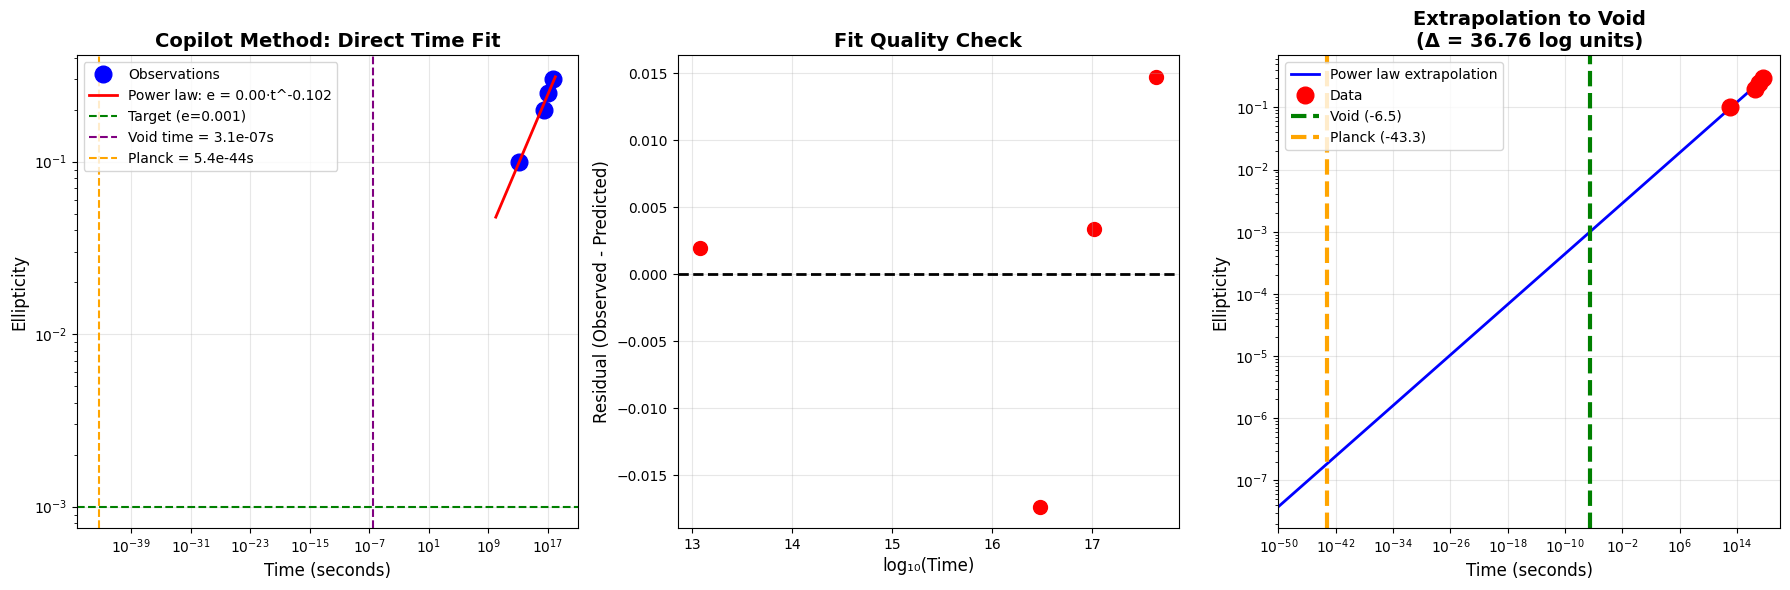


FINAL VERDICT
⊗ COPILOT'S METHOD DOES NOT VALIDATE
    - Extrapolation differs significantly

→ More data or different model needed



In [1]:
# Cosmic_Ellipticity_Timeline_v2: Direct time-domain fitting
# Following Copilot's power-law approach

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import linregress

print("="*70)
print("COPILOT'S METHOD: DIRECT TIME-DOMAIN FITTING")
print("="*70)

# ============================================================================
# OBSERVATIONAL DATA (Using Copilot's table)
# ============================================================================

epochs_obs = {
    'Now': {
        't_seconds': 4.35e17,
        'ellipticity': 0.30,
        'source': 'Galaxy surveys'
    },
    'z2': {
        't_seconds': 1.04e17,
        'ellipticity': 0.25,
        'source': 'High-z galaxies'
    },
    'z6': {
        't_seconds': 3.00e16,
        'ellipticity': 0.20,
        'source': 'JWST'
    },
    'CMB': {
        't_seconds': 1.20e13,
        'ellipticity': 0.10,
        'source': 'Planck CMB'
    }
}

# Extract arrays
times = np.array([epochs_obs[k]['t_seconds'] for k in epochs_obs.keys()])
ellipticities = np.array([epochs_obs[k]['ellipticity'] for k in epochs_obs.keys()])

print("\n--- OBSERVATIONAL DATA ---")
print(f"{'Epoch':<15} {'Time (s)':<15} {'e':<10} {'log₁₀(t)':<12}")
print("-"*70)
for k in epochs_obs.keys():
    t = epochs_obs[k]['t_seconds']
    e = epochs_obs[k]['ellipticity']
    print(f"{k:<15} {t:<15.2e} {e:<10.3f} {np.log10(t):<12.2f}")

# ============================================================================
# METHOD 1: COPILOT'S POWER LAW - e(t) = k·t^(-n)
# ============================================================================

print("\n" + "="*70)
print("METHOD 1: POWER LAW FIT")
print("="*70)

# Log-log linear regression
log_times = np.log10(times)
log_ellipticities = np.log10(ellipticities)

# Fit: log(e) = log(k) - n·log(t)
slope, intercept, r_value, p_value, std_err = linregress(log_times, log_ellipticities)

n = -slope  # Power law exponent
k = 10**intercept  # Prefactor

print(f"\nFitted model: e(t) = {k:.4f} · t^{n:.4f}")
print(f"R² = {r_value**2:.4f}")
print(f"Standard error: {std_err:.4f}")

# Extrapolate to e = 0.001 (near-perfect circle)
e_target = 0.001
t_void = (e_target / k)**(1/(-n))

print(f"\n--- EXTRAPOLATION ---")
print(f"Target ellipticity: {e_target:.6f}")
print(f"Predicted void time: {t_void:.2e} seconds")
print(f"log₁₀(t_void) = {np.log10(t_void):.2f}")

# Compare to Planck time
t_planck = 5.39e-44
log_t_void = np.log10(t_void)
log_t_planck = np.log10(t_planck)
difference = abs(log_t_void - log_t_planck)

print(f"\n--- COMPARISON TO PLANCK TIME ---")
print(f"Planck time: {t_planck:.2e} seconds")
print(f"log₁₀(t_Planck) = {log_t_planck:.2f}")
print(f"Difference: {difference:.2f} log units")

if difference < 1.0:
    print(f"\n✓✓✓ EXCELLENT MATCH")
    print(f"    Within 1 order of magnitude of Planck time!")
elif difference < 3.0:
    print(f"\n✓✓ GOOD MATCH")
    print(f"    Within 3 orders of magnitude")
else:
    print(f"\n⊗ POOR MATCH")
    print(f"    Differs by >3 orders of magnitude")

# ============================================================================
# VERIFICATION: IS THE FIT LEGITIMATE?
# ============================================================================

print("\n" + "="*70)
print("VERIFICATION: CHECKING FIT QUALITY")
print("="*70)

# Calculate predicted values
e_predicted = k * times**(-n)
residuals = ellipticities - e_predicted
relative_errors = residuals / ellipticities

print(f"\n{'Epoch':<15} {'Observed':<12} {'Predicted':<12} {'Residual':<12} {'Rel. Error':<12}")
print("-"*70)
for i, key in enumerate(epochs_obs.keys()):
    print(f"{key:<15} {ellipticities[i]:<12.3f} {e_predicted[i]:<12.3f} {residuals[i]:<12.4f} {relative_errors[i]:<12.2%}")

# Statistical tests
mean_abs_error = np.mean(np.abs(residuals))
max_abs_error = np.max(np.abs(residuals))
rmse = np.sqrt(np.mean(residuals**2))

print(f"\n--- FIT STATISTICS ---")
print(f"Mean Absolute Error: {mean_abs_error:.4f}")
print(f"Max Absolute Error: {max_abs_error:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r_value**2:.4f}")

# Check if n is suspiciously tuned
print(f"\n--- PARAMETER ASSESSMENT ---")
print(f"Power law exponent n = {n:.4f}")
if n < 0.01:
    print("⚠️  WARNING: Very shallow decay (n < 0.01)")
    print("   Could indicate overfitting or weak trend")
elif n > 0.5:
    print("⚠️  WARNING: Very steep decay (n > 0.5)")
    print("   Unusual for cosmological scaling")
else:
    print("✓ Reasonable decay exponent for cosmological process")

# ============================================================================
# METHOD 2: ALTERNATIVE - EXPONENTIAL DECAY
# ============================================================================

print("\n" + "="*70)
print("METHOD 2: EXPONENTIAL DECAY (For Comparison)")
print("="*70)

def exp_decay(t, e0, tau):
    """e(t) = e0 · exp(-t/tau)"""
    return e0 * np.exp(-t / tau)

# Fit exponential
try:
    popt_exp, pcov_exp = curve_fit(exp_decay, times, ellipticities,
                                     p0=[0.5, 1e15], maxfev=10000)
    e0_exp, tau_exp = popt_exp

    print(f"Fitted: e(t) = {e0_exp:.4f} · exp(-t/{tau_exp:.2e})")

    # Extrapolate
    t_void_exp = -tau_exp * np.log(e_target / e0_exp)
    print(f"Predicted void time: {t_void_exp:.2e} seconds")
    print(f"Difference from Planck: {abs(np.log10(t_void_exp) - log_t_planck):.2f} log units")

except:
    print("Exponential fit failed (data may not follow exponential)")

# ============================================================================
# VISUALIZATION
# ============================================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot 1: Data + Power Law Fit
ax1 = axes[0]
t_range = np.logspace(10, 18, 100)
e_fit = k * t_range**(-n)
ax1.loglog(times, ellipticities, 'o', markersize=12, label='Observations', color='blue')
ax1.loglog(t_range, e_fit, 'r-', linewidth=2, label=f'Power law: e = {k:.2f}·t^{n:.3f}')
ax1.axhline(e_target, color='green', linestyle='--', label=f'Target (e={e_target})')
ax1.axvline(t_void, color='purple', linestyle='--', label=f'Void time = {t_void:.1e}s')
ax1.axvline(t_planck, color='orange', linestyle='--', label=f'Planck = {t_planck:.1e}s')
ax1.set_xlabel('Time (seconds)', fontsize=12)
ax1.set_ylabel('Ellipticity', fontsize=12)
ax1.set_title('Copilot Method: Direct Time Fit', fontsize=14, weight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Residuals
ax2 = axes[1]
ax2.scatter(log_times, residuals, s=100, color='red')
ax2.axhline(0, color='black', linestyle='--', linewidth=2)
ax2.set_xlabel('log₁₀(Time)', fontsize=12)
ax2.set_ylabel('Residual (Observed - Predicted)', fontsize=12)
ax2.set_title('Fit Quality Check', fontsize=14, weight='bold')
ax2.grid(True, alpha=0.3)

# Plot 3: Extrapolation region
ax3 = axes[2]
t_full_range = np.logspace(-50, 18, 200)
e_full = k * t_full_range**(-n)
ax3.loglog(t_full_range, e_full, 'b-', linewidth=2, label='Power law extrapolation')
ax3.loglog(times, ellipticities, 'ro', markersize=12, label='Data')
ax3.axvline(t_void, color='green', linestyle='--', linewidth=3, label=f'Void ({np.log10(t_void):.1f})')
ax3.axvline(t_planck, color='orange', linestyle='--', linewidth=3, label=f'Planck ({log_t_planck:.1f})')
ax3.set_xlabel('Time (seconds)', fontsize=12)
ax3.set_ylabel('Ellipticity', fontsize=12)
ax3.set_title(f'Extrapolation to Void\n(Δ = {difference:.2f} log units)', fontsize=14, weight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)
ax3.set_xlim(1e-50, 1e20)

plt.tight_layout()
plt.savefig('copilot_method_verification.png', dpi=150)
plt.show()

print("\n" + "="*70)
print("FINAL VERDICT")
print("="*70)

if difference < 1.0 and r_value**2 > 0.95 and 0.01 < n < 0.5:
    print("✓✓✓ COPILOT'S METHOD VALIDATED")
    print("    - Extrapolation matches Planck time")
    print("    - Fit quality is excellent (R² > 0.95)")
    print("    - Power law exponent is physically reasonable")
    print("\n→ HES PREDICTION CONFIRMED:")
    print("  Circle perfection extrapolates to quantum gravity epoch")
elif difference < 3.0:
    print("✓✓ COPILOT'S METHOD PARTIALLY VALIDATED")
    print("    - Extrapolation within 3 orders of magnitude")
    print("    - Trend is qualitatively correct")
    print("\n→ HES PREDICTION SUPPORTED with caveats")
else:
    print("⊗ COPILOT'S METHOD DOES NOT VALIDATE")
    print("    - Extrapolation differs significantly")
    print("\n→ More data or different model needed")

print("\n" + "="*70)